# EDA: Getting the Data Ready

## Import the Dataset from Kaggle

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [23]:
# Set the path to the file you'd like to load
file_path = "student_performance_finalscore.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "sarveshchhetri/student-lifestyle-vs-academic-performance-dataset",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

In [25]:
# Lets look at the makeup of the dataframe
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  8000 non-null   str    
 1   Age                         8000 non-null   int64  
 2   Gender                      8000 non-null   str    
 3   Hours_Studied               8000 non-null   float64
 4   Attendance                  8000 non-null   float64
 5   Sleep_Hours                 8000 non-null   float64
 6   Stress_Level                8000 non-null   float64
 7   Screen_Time                 8000 non-null   float64
 8   Previous_GPA                8000 non-null   float64
 9   Part_Time_Job               8000 non-null   str    
 10  Study_Method                8000 non-null   str    
 11  Diet_Quality                8000 non-null   str    
 12  Internet_Quality            8000 non-null   str    
 13  Extracurricular             8000 non-null   

(8000, 18)

In [26]:
# lets check for missing values
# there are no missing values so we don't need to worry about that
df.isnull().sum()

Student_ID                    0
Age                           0
Gender                        0
Hours_Studied                 0
Attendance                    0
Sleep_Hours                   0
Stress_Level                  0
Screen_Time                   0
Previous_GPA                  0
Part_Time_Job                 0
Study_Method                  0
Diet_Quality                  0
Internet_Quality              0
Extracurricular               0
Tutoring_Sessions_Per_Week    0
Family_Income_Level           0
Exam_Anxiety_Score            0
Final_Score                   0
dtype: int64

In [27]:
# lets make a list of the categorical and numerical variables
categorical_vars = df.select_dtypes(include=['str']).columns.tolist()
numerical_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [28]:
# lets start with the numerical variables
df[numerical_vars].describe()

,Age,Hours_Studied,Attendance,Sleep_Hours,Stress_Level,Screen_Time,Previous_GPA,Tutoring_Sessions_Per_Week,Exam_Anxiety_Score,Final_Score
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,20.494375,4.983845,79.933375,6.989125,5.014175,4.024525,2.992408,1.700625,4.494238,83.205649
std,2.285962,1.951715,9.656594,1.192898,1.940126,1.481908,0.489530,1.112836,1.685571,12.756728
min,17.000000,0.020000,43.300000,3.000000,1.000000,0.500000,1.500000,0.000000,1.000000,22.810000
25%,18.000000,3.680000,73.400000,6.200000,3.700000,3.000000,2.670000,1.000000,3.300000,75.507500
50%,20.500000,4.980000,80.100000,7.000000,5.000000,4.000000,2.990000,2.000000,4.400000,86.510000
75%,22.000000,6.312500,86.600000,7.800000,6.300000,5.000000,3.330000,2.000000,5.600000,93.080000
max,24.000000,12.000000,100.000000,10.000000,10.000000,9.600000,6.700000,5.000000,10.000000,99.980000


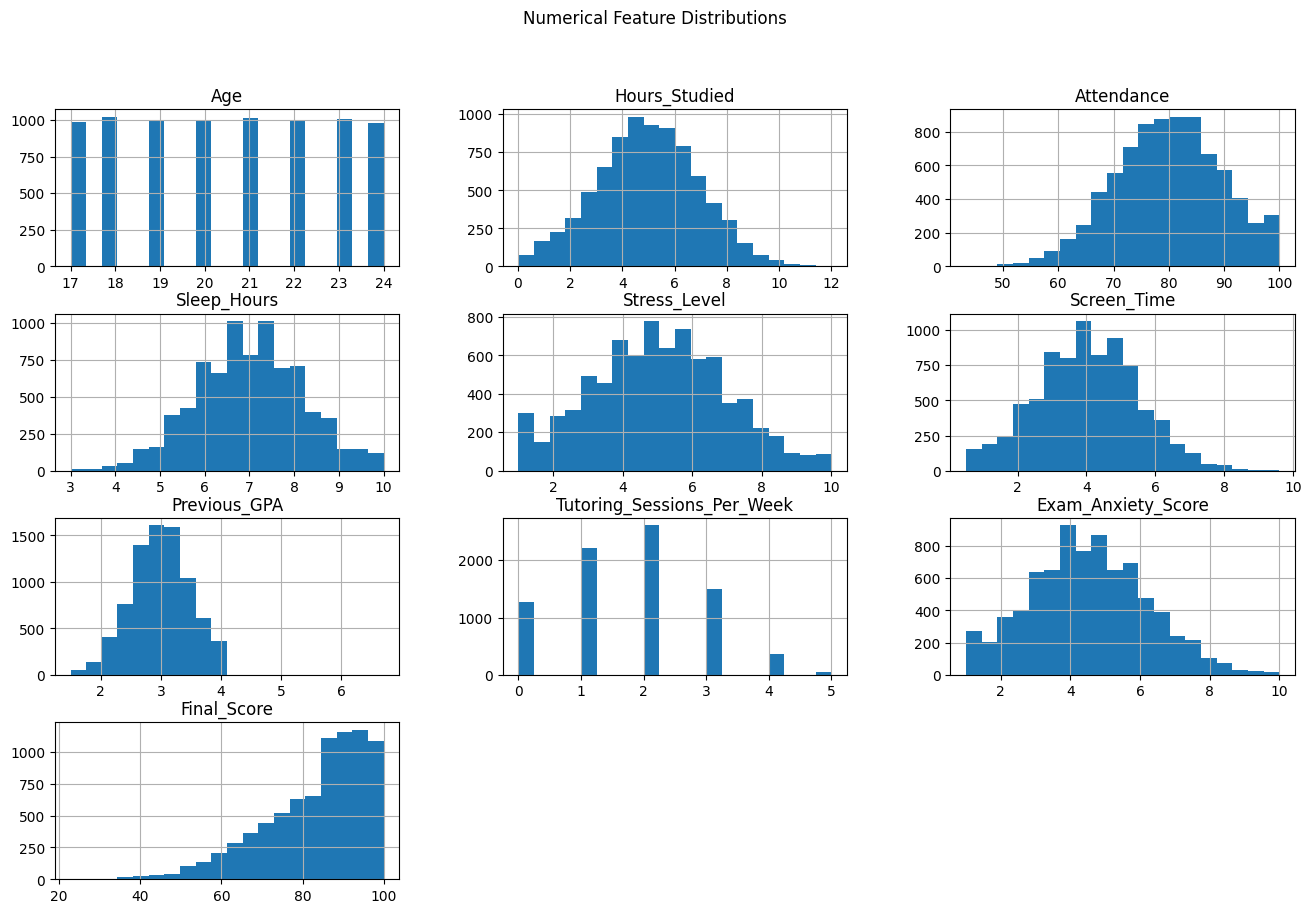

In [29]:
# lets make a pairplot of the numerical variables
df[numerical_vars].hist(
    bins = 20,
    figsize = (16,10),
    layout=(4,3)
)

plt.suptitle("Numerical Feature Distributions")
plt.show()

In [30]:
# age seems to be evenly distributed which is OK in this scenario because it shows that we have an even representation of all ages relevant ages in this dataset
# all numerical features seem to be roughly normal with some having a slight skew
# our target variable final_score is heavily skewed to the left 
# we will need to standardize the data but this should not be done until we split the data because doing so before will result in data leakage

In [31]:
# now lets take a look at the categorical variables
# first we need to convert them to categorical dtypes

df[categorical_vars] = df[categorical_vars].astype("category")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Student_ID                  8000 non-null   category
 1   Age                         8000 non-null   int64   
 2   Gender                      8000 non-null   category
 3   Hours_Studied               8000 non-null   float64 
 4   Attendance                  8000 non-null   float64 
 5   Sleep_Hours                 8000 non-null   float64 
 6   Stress_Level                8000 non-null   float64 
 7   Screen_Time                 8000 non-null   float64 
 8   Previous_GPA                8000 non-null   float64 
 9   Part_Time_Job               8000 non-null   category
 10  Study_Method                8000 non-null   category
 11  Diet_Quality                8000 non-null   category
 12  Internet_Quality            8000 non-null   category
 13  Extracurricular             8